In [7]:
from pymongo import MongoClient
from bson import ObjectId

MONGO_URI = "mongodb://localhost:27017/?replicaSet=rs0"
MONGO_DB_NAME = "simlab"


client = MongoClient(MONGO_URI)
try:
    db = client[MONGO_DB_NAME]
    result = list(db["simulations"].find({"experiment_id": ObjectId('69b0a6640a6e7a58e3654c69')}, {"individual_id": 1, "random_seed": 1, "network_metrics": 1}))
finally:
    client.close()
    
print(result)

[{'_id': ObjectId('69b0a66518535da9480ae8c6'), 'individual_id': 5107467298376595976, 'random_seed': 336157, 'network_metrics': {'latency': 109.66996931170539, 'energy': 2962624.0, 'throughput': 19334.0, 'cpu_energy_mj': 244976.0, 'lpm_energy_mj': 0.0, 'radio_tx_energy_mj': 4132.0, 'radio_rx_energy_mj': 2713516.0, 'total_sent': 11657.0, 'total_received': 9018.0, 'server_sent': 19334.0, 'bytes_tx': 0.0, 'bytes_rx': 132.0, 'server_bytes_rx': 0.0, 'r2n_latency': 473.73958790004383, 'n2r_latency': 1.6766238410177397e+19, 'hops': 1.2716352476983779, 'rtt_latency': 109.66996931170539}}, {'_id': ObjectId('69b0a66518535da9480ae8ce'), 'individual_id': 5107467298376595976, 'random_seed': 667370, 'network_metrics': {'latency': 84.56860364267129, 'energy': 3035826.0, 'throughput': 18692.0, 'cpu_energy_mj': 250905.0, 'lpm_energy_mj': 0.0, 'radio_tx_energy_mj': 2852.0, 'radio_rx_energy_mj': 2782069.0, 'total_sent': 11745.0, 'total_received': 8054.0, 'server_sent': 18692.0, 'bytes_tx': 0.0, 'bytes_rx'

In [8]:
from typing import Any
import pandas as pd

def json_to_dataframe(data: list[dict[str, Any]]) -> pd.DataFrame:
    rows = []

    for doc in data:
        metrics = doc.get("network_metrics", {})        
        row = {
            "id": str(doc.get("random_seed"))
        }
        row.update(metrics)
        rows.append(row)
    return pd.DataFrame(rows)

df = json_to_dataframe(result)

print(df)

         id     latency     energy  throughput  cpu_energy_mj  lpm_energy_mj  \
0    336157  109.669969  2962624.0     19334.0       244976.0            0.0   
1    667370   84.568604  3035826.0     18692.0       250905.0            0.0   
2     35239  109.243967  3152425.0     19142.0       261072.0            0.0   
3      5881  106.857256  3003842.0     19292.0       248384.0            0.0   
4    656466   72.832207  3001059.0     18642.0       249355.0            0.0   
..      ...         ...        ...         ...            ...            ...   
98    48353  106.287479  3023177.0     19490.0       250473.0            0.0   
99   219533  108.767050  2962781.0     19292.0       244859.0            0.0   
100  123456  116.611572  2964168.0     18619.0       243531.0            0.0   
101  234567   81.209223  3105767.0     18683.0       256580.0            0.0   
102  345678   71.868130  3091493.0     18391.0       255677.0            0.0   

     radio_tx_energy_mj  radio_rx_energ

                metric          mean           var           std  \
0              latency  9.536618e+01  2.539245e+02  1.593501e+01   
1               energy  3.003358e+06  3.419394e+09  5.847559e+04   
2           throughput  1.886596e+04  1.510852e+05  3.886968e+02   
3        cpu_energy_mj  2.476999e+05  2.447324e+07  4.947044e+03   
4        lpm_energy_mj  0.000000e+00  0.000000e+00  0.000000e+00   
5   radio_tx_energy_mj  3.412641e+03  6.172613e+05  7.856598e+02   
6   radio_rx_energy_mj  2.752245e+06  2.882618e+09  5.369002e+04   
7           total_sent  1.157581e+04  1.036326e+04  1.018001e+02   
8       total_received  8.445757e+03  4.198113e+05  6.479285e+02   
9          server_sent  1.886596e+04  1.510852e+05  3.886968e+02   
10            bytes_tx  0.000000e+00  0.000000e+00  0.000000e+00   
11            bytes_rx  1.279223e+02  2.048567e+02  1.431281e+01   
12     server_bytes_rx  0.000000e+00  0.000000e+00  0.000000e+00   
13         r2n_latency  4.677686e+18  1.306036e+

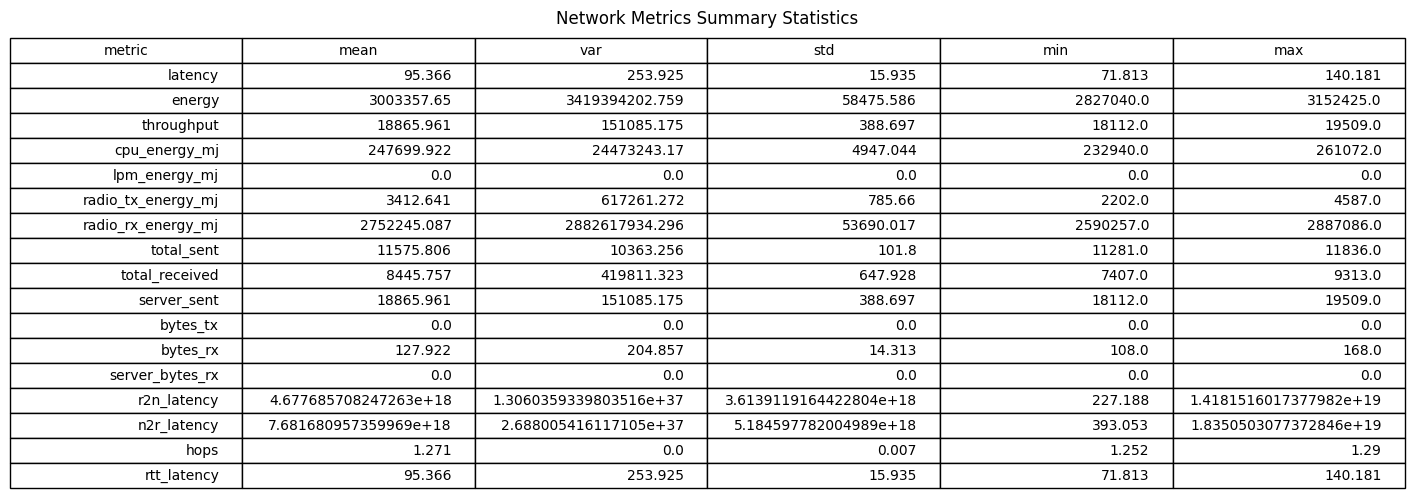

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

columns = df.columns.tolist()
columns.remove("id")

# ------------------------------------------------------------
# Build statistics table
# ------------------------------------------------------------
stats = []

for column in columns:
    stats.append({
        "metric": column,
        "mean": df[column].mean(),
        "var": df[column].var(),
        "std": df[column].std(),
        "min": df[column].min(),
        "max": df[column].max(),
    })

stats_df = pd.DataFrame(stats)

print(stats_df)

# ------------------------------------------------------------
# Plot table
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis("off")

table = ax.table(
    cellText=stats_df.round(3).values,
    colLabels=stats_df.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.8, 1.5)

plt.title("Network Metrics Summary Statistics")
plt.show()

103
       metric          mean           var           std        cv  \
0     latency  9.536618e+01  2.539245e+02     15.935010  0.167093   
1      energy  3.003358e+06  3.419394e+09  58475.586382  0.019470   
2  throughput  1.886596e+04  1.510852e+05    388.696765  0.020603   

            se        ci_low       ci_high  
0     1.570123  9.228873e+01  9.844362e+01  
1  5761.770732  2.992065e+06  3.014651e+06  
2    38.299430  1.879089e+04  1.894103e+04  
       metric       mean        var        std         cv         se  \
0     latency  9.537e+01  2.539e+02  1.594e+01  1.671e-01  1.570e+00   
1      energy  3.003e+06  3.419e+09  5.848e+04  1.947e-02  5.762e+03   
2  throughput  1.887e+04  1.511e+05  3.887e+02  2.060e-02  3.830e+01   

      ci_low    ci_high  
0  9.229e+01  9.844e+01  
1  2.992e+06  3.015e+06  
2  1.879e+04  1.894e+04  


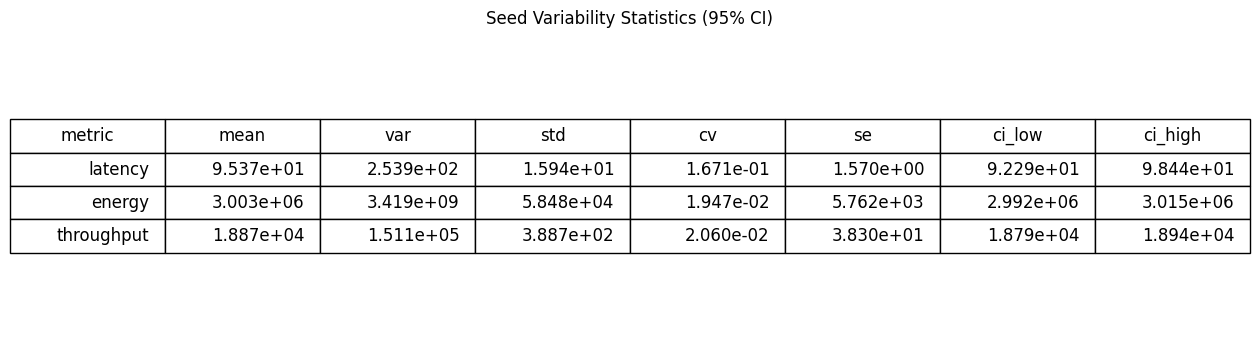

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Metrics of interest
# ------------------------------------------------------------
metrics = ["latency", "energy", "throughput"]

n = len(df)
print(n)
# ------------------------------------------------------------
# Build statistics table
# ------------------------------------------------------------
stats = []

for column in metrics:

    mean = df[column].mean()
    var = df[column].var()
    std = df[column].std()

    cv = std / mean if mean != 0 else np.nan
    se = std / np.sqrt(n)

    ci_low = mean - 1.96 * se
    ci_high = mean + 1.96 * se

    stats.append({
        "metric": column,
        "mean": mean,
        "var": var,
        "std": std,
        "cv": cv,
        "se": se,
        "ci_low": ci_low,
        "ci_high": ci_high
    })

stats_df = pd.DataFrame(stats)

print(stats_df)

# ------------------------------------------------------------
# Convert numeric columns to scientific notation
# ------------------------------------------------------------
def sci(x):
    if isinstance(x, (int, float, np.floating)):
        return f"{x:.3e}"
    return x

display_df = stats_df.copy()

for col in display_df.columns[1:]:
    display_df[col] = display_df[col].apply(sci)

print(display_df)

# ------------------------------------------------------------
# Plot table
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("off")

table = ax.table(
    cellText=display_df.values,
    colLabels=display_df.columns,
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(2.0, 2.0)

plt.title("Seed Variability Statistics (95% CI)")
plt.show()

In [11]:
import numpy as np

# ------------------------------------------------------------
# James-Stein estimator
# ------------------------------------------------------------
def james_stein_to_mean(means: np.ndarray, variances: np.ndarray) -> np.ndarray:
    k = means.size
    if k < 3:
        return means

    mu_bar: np.ndarray = means.mean()
    sigma2: float = np.mean(variances)

    diff2: float = np.sum((means - mu_bar) ** 2)

    if diff2 <= 0 or sigma2 <= 0:
        return means
    
    shrink: float = max(0, 1 - ((k - 2) * sigma2) / diff2)
    
    print(f"Shrinkage factor: {shrink:.4f}")
    print(f"Original means: {means}")
    print(f"Global mean (mu_bar): {mu_bar:.4f}")
    print(f"Variances: {variances}")

    return mu_bar + shrink * (means - mu_bar)


def james_stein_heteroscedastic(means: np.ndarray, variances: np.ndarray) -> np.ndarray:
    k = means.size
    if k < 3:
        return means

    mu_bar: float = means.mean()

    diff2: float = np.sum((means - mu_bar) ** 2)

    if diff2 <= 0:
        return means

    shrink: np.ndarray = 1 - ((k - 2) * variances) / diff2
    shrink = np.clip(shrink, 0.0, 1.0)

    print(f"Shrinkage factors: {shrink}")
    print(f"Original means: {means}")
    print(f"Global mean (mu_bar): {mu_bar:.4f}")
    print(f"Variances: {variances}")

    return mu_bar + shrink * (means - mu_bar)


def james_stein_to_opt(means: np.ndarray, variances: np.ndarray, mu_bar: np.ndarray) -> np.ndarray:
    k = means.size
    if k < 3:
        return means

    sigma2: float = np.mean(variances)

    diff2: float = np.sum((means - means.mean()) ** 2)

    if diff2 <= 0 or sigma2 <= 0:
        return means
    
    shrink: float = max(0, 1 - ((k - 2) * sigma2) / diff2)
    
    print(f"Shrinkage factor: {shrink:.4f}")
    print(f"Original means: {means}")
    print(f"Variances: {variances}")

    return mu_bar + shrink * (means - mu_bar)


def james_stein(means: np.ndarray, variances: np.ndarray) -> np.ndarray:
    k = means.size
    if k < 3:
        return means

    return [(1-variances[i]*(k-2)/means.mean()**2)*means[i] for i in range(len(means))]


# ------------------------------------------------------------
# Build statistics table
# ------------------------------------------------------------
columns = df.columns.tolist()
columns.remove("id")

means = []
variances = []
stats = []
directions: np.ndarray = []

for column in ["latency", "throughput", "energy"]:
    m = df[column].mean()
    v = df[column].var()

    means.append(m)
    variances.append(v)
    if column == "latency" or column == "energy":
        directions.append(df[column].max())
    else:
        directions.append(df[column].min())

means = np.array(means)
variances = np.array(variances)

print(f"Original means:\n\t{means[0]:.4f}, {means[1]:.4f}, {means[2]:.4f}")
print("---")

js_values = james_stein(means, variances)
print(f'James-Stein estimates:\n\t{js_values[0]:.4f}, {js_values[1]:.4f}, {js_values[2]:.4f}')
print("---")

js_values_to_mean = james_stein_to_mean(means, variances)
print(f'James-Stein estimates (to mean):\n\t{js_values_to_mean[0]:.4f}, {js_values_to_mean[1]:.4f}, {js_values_to_mean[2]:.4f}')
print("---")

js_values_heteroscedastic = james_stein_heteroscedastic(means, variances)
print(f'James-Stein estimates (heteroscedastic):\n\t{js_values_heteroscedastic[0]:.4f}, {js_values_heteroscedastic[1]:.4f}, {js_values_heteroscedastic[2]:.4f}')
print("---")

js_values_to_opt = james_stein_to_opt(means, variances, directions)
print(f'James-Stein estimates (to opt):\n\t{js_values_to_opt[0]:.4f}, {js_values_to_opt[1]:.4f}, {js_values_to_opt[2]:.4f}')

Original means:
	95.3662, 18865.9612, 3003357.6505
---
James-Stein estimates:
	95.3662, 18865.9584, 2993239.1039
---
Shrinkage factor: 0.9998
Original means: [9.53661751e+01 1.88659612e+04 3.00335765e+06]
Global mean (mu_bar): 1007439.6593
Variances: [2.53924532e+02 1.51085175e+05 3.41939420e+09]
James-Stein estimates (to mean):
	287.5141, 19054.5286, 3002976.9351
---
Shrinkage factors: [1.         0.99999997 0.99942778]
Original means: [9.53661751e+01 1.88659612e+04 3.00335765e+06]
Global mean (mu_bar): 1007439.6593
Variances: [2.53924532e+02 1.51085175e+05 3.41939420e+09]
James-Stein estimates (heteroscedastic):
	95.3662, 18865.9862, 3002215.5550
---
Shrinkage factor: 0.9998
Original means: [9.53661751e+01 1.88659612e+04 3.00335765e+06]
Variances: [2.53924532e+02 1.51085175e+05 3.41939420e+09]
James-Stein estimates (to opt):
	95.3747, 18865.8173, 3003386.0846



$$
\epsilon_{js}=v+\Big(1-\frac{d-1}{||\bar{\mu}-v||^2}\Big)\sigma^2I(\bar{\mu}-v)
$$

sendo:
- $\sigma^2I$ é a matriz de covarância.
- $\bar{\mu}=\frac{1}{N}\sum_{i=1}^N x_i$ sendo $x_i\in\mathbb{R}^d$.
- $v\in\mathbb{R}^d$.